<a href="https://colab.research.google.com/github/yongik-jang/ml-for-very-newbies/blob/main/notebooks/03_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML for Very Newbies — Extra: Physics-Informed Neural Networks

Not covered in the lecture. This is a short example of what you can do once you have the pieces from the slides:
a network, a loss, autograd, and a training loop — applied to a differential equation instead of a dataset.

| notebook | uses from the slides |
|---|---|
| 1. The problem | — |
| 2. Exact solution | — |
| 3. The network | MLP, activation functions |
| 4. Loss function | loss as "how wrong", autograd (`01_examples` §2.1) |
| 5. Training | the five-line training loop |
| 6. Result | overfitting vs. generalization, seen differently |

## 1. The problem: a damped pendulum

$$
\theta''(t) + 2\beta\,\theta'(t) + \omega_0^2\,\theta(t) = 0, \qquad
\theta(t_0) = \theta_0, \quad \theta'(t_0) = v_0
$$

- $\theta(t)$: angle of the pendulum
- $\beta$: damping coefficient (friction, air resistance)
- $\omega_0$: natural angular frequency

**Key idea.** A network takes $t$ and returns $\hat\theta(t)$. With automatic differentiation we get
$\hat\theta'(t)$ and $\hat\theta''(t)$ from the same network, so we can ask it to satisfy
(a) the equation and (b) the initial conditions — not just to fit data points.

The equation has an exact solution, so we can check how well the network does.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("numpy    ", np.__version__)
print("torch    ", torch.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device   ", device)

torch.manual_seed(0)
np.random.seed(0)

numpy     1.26.4
torch     2.2.2
device    cpu


In [2]:
beta   = 0.5    # damping coefficient
omega0 = 3.0    # natural angular frequency
t0     = 0.0    # initial time
theta0 = 1.0    # initial angle        theta(t0)  = theta0
v0     = 0.0    # initial angular velocity  theta'(t0) = v0
t_end  = 5.0    # solve on [t0, t_end]

## 2. Exact solution

When $\beta < \omega_0$ (under-damped), the exact solution is

$$
\theta(t) = e^{-\beta (t-t_0)}\big(A\cos\omega_d (t-t_0) + B\sin\omega_d (t-t_0)\big),
\quad \omega_d = \sqrt{\omega_0^2 - \beta^2}
$$

with $A = \theta_0$ and $B = (v_0 + \beta\theta_0)/\omega_d$.

In [3]:
def exact_solution(t):
    # under-damped case, beta < omega0
    omega_d = np.sqrt(omega0**2 - beta**2)
    A = theta0
    B = (v0 + beta * theta0) / omega_d
    s = t - t0
    return np.exp(-beta * s) * (A * np.cos(omega_d * s) + B * np.sin(omega_d * s))

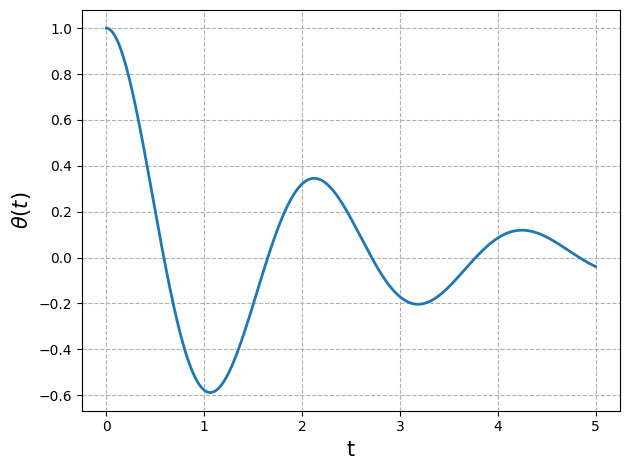

In [4]:
t_span = np.linspace(t0, t_end, 500)

plt.figure()
plt.plot(t_span, exact_solution(t_span), lw=2)
plt.xlabel("t", fontsize=15)
plt.ylabel(r"$\theta(t)$", fontsize=15)
plt.grid(ls='--')
plt.tight_layout()
plt.show()

## 3. The network

Input $t$, output $\hat\theta(t)$. Three hidden layers of width 32 with tanh —
smooth activations matter here, because we will differentiate the network twice.

In [5]:
class DNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), 
            nn.Tanh(),
            nn.Linear(hidden, hidden), 
            nn.Tanh(),
            nn.Linear(hidden, hidden), 
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t):
        return self.net(t)

net = DNN()
print(net)
print("number of parameters:", sum(p.numel() for p in net.parameters()))

DNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
number of parameters: 2209


## 4. Loss function

Three terms. The first is the usual data fit; the other two are the physics.

$$
\mathcal{L}_{\text{data}} = \frac{1}{N}\sum_i \big(\hat\theta(t_i) - \theta_i\big)^2
\qquad \text{(measured points)}
$$
$$
\mathcal{L}_{\text{eom}} = \frac{1}{N_f}\sum_j \Big(\hat\theta''(t_j) + 2\beta\,\hat\theta'(t_j) + \omega_0^2\,\hat\theta(t_j)\Big)^2
\qquad \text{(equation of motion, on a grid of } t_j\text{)}
$$
$$
\mathcal{L}_{\text{init}} = \big(\hat\theta(t_0) - \theta_0\big)^2 + \big(\hat\theta'(t_0) - v_0\big)^2
\qquad \text{(initial conditions)}
$$
$$
\mathcal{L} = \mathcal{L}_{\text{data}} + \mathcal{L}_{\text{eom}} + \mathcal{L}_{\text{init}}
$$

The derivatives $\hat\theta'$, $\hat\theta''$ come from `torch.autograd.grad` — the same machinery as `loss.backward()`,
but now differentiating with respect to the *input* $t$ instead of the parameters.
`create_graph=True` keeps the graph so the derivative itself can be differentiated again and trained through.


In [6]:
def pinn_loss(model):
    # equation residual on a grid of collocation points
    t_f = torch.linspace(t0, t_end, 200, device=device).view(-1, 1).requires_grad_(True)
    theta = model(t_f)
    d_theta,  = torch.autograd.grad(theta, t_f, grad_outputs=torch.ones_like(theta), create_graph=True)
    d2_theta, = torch.autograd.grad(d_theta, t_f, grad_outputs=torch.ones_like(d_theta), create_graph=True)
    residual = d2_theta + 2*beta*d_theta + omega0**2*theta
    loss_eq = torch.mean(residual**2)

    # initial conditions at t0
    t_init = torch.tensor([[t0]], device=device, requires_grad=True)
    theta_i = model(t_init)
    d_theta_i, = torch.autograd.grad(theta_i, t_init, grad_outputs=torch.ones_like(theta_i), create_graph=True)
    loss_init = torch.mean((theta_i - theta0)**2 + (d_theta_i - v0)**2)

    return loss_eq + loss_init

## 5. Training: data only vs. data + physics

Ten noisy measurements on $[0, 2]$ only. Both networks see the same points; the PINN also sees the equation on $[0, 5]$.

In [7]:
def train_nn(model, data, epochs, lr, pinn):
    # pinn=False: fit the data only.  pinn=True: add the equation and initial-condition terms.
    model = model.to(device)
    MSE = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t, theta = data[:, 0:1].to(device), data[:, 1:2].to(device)
    history = []
    model.train()
    for epoch in range(1, epochs + 1):
        opt.zero_grad()
        pred = model(t)
        loss = MSE(pred, theta)
        if pinn:
            loss = loss + pinn_loss(model)
        loss.backward()
        opt.step()

        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"epoch {epoch:5d} | loss {loss.item():.2e}")
    return model, history

data shape:  torch.Size([10, 2])


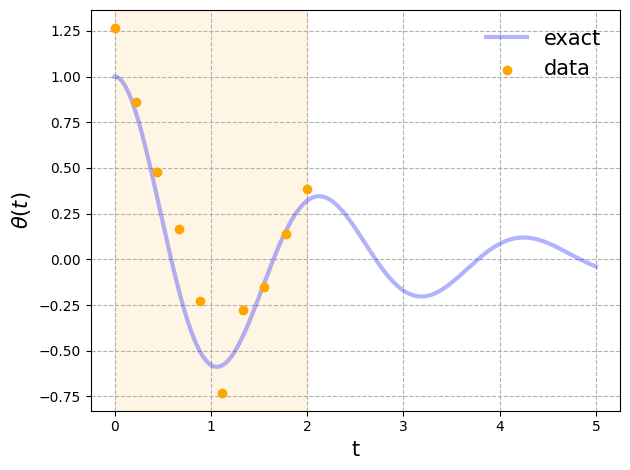

In [8]:
t_data = np.linspace(0.0, 2.0, 10)                                # measurements only on [0, 2]
theta_data = exact_solution(t_data) + np.random.normal(0, 0.15, len(t_data))
data = torch.tensor(np.stack([t_data, theta_data], axis=1), dtype=torch.float32)
print("data shape: ", data.shape)

plt.figure()
plt.plot(t_span, exact_solution(t_span), c='blue', lw=3, alpha=0.3, label="exact")
plt.scatter(t_data, theta_data, c='orange', zorder=3, label="data")
plt.axvspan(0, 2, color='orange', alpha=0.1)
plt.xlabel("t", fontsize=15)
plt.ylabel(r"$\theta(t)$", fontsize=15)
plt.legend(fontsize=15, frameon=False)
plt.grid(ls='--')
plt.tight_layout()
plt.show()

In [9]:
torch.manual_seed(0)
model_nn, hist_nn = train_nn(DNN(), data, epochs=10000, lr=1e-3, pinn=False)    # data only

/Users/yongik.jang/Work/venv_py_3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


epoch   100 | loss 8.97e-02
epoch   200 | loss 1.11e-02
epoch   300 | loss 9.80e-03
epoch   400 | loss 8.30e-03
epoch   500 | loss 6.60e-03
epoch   600 | loss 5.16e-03
epoch   700 | loss 4.25e-03
epoch   800 | loss 3.61e-03
epoch   900 | loss 3.01e-03
epoch  1000 | loss 2.60e-03
epoch  1100 | loss 1.81e-03
epoch  1200 | loss 1.11e-03
epoch  1300 | loss 4.66e-04
epoch  1400 | loss 2.01e-04
epoch  1500 | loss 1.33e-04
epoch  1600 | loss 1.13e-04
epoch  1700 | loss 1.01e-04
epoch  1800 | loss 2.70e-04
epoch  1900 | loss 8.28e-05
epoch  2000 | loss 7.52e-05
epoch  2100 | loss 6.90e-05
epoch  2200 | loss 6.19e-05
epoch  2300 | loss 5.61e-05
epoch  2400 | loss 5.05e-05
epoch  2500 | loss 4.55e-05
epoch  2600 | loss 4.09e-05
epoch  2700 | loss 3.66e-05
epoch  2800 | loss 3.27e-05
epoch  2900 | loss 6.28e-05
epoch  3000 | loss 2.58e-05
epoch  3100 | loss 2.28e-05
epoch  3200 | loss 3.35e-05
epoch  3300 | loss 1.75e-05
epoch  3400 | loss 1.53e-05
epoch  3500 | loss 1.62e-05
epoch  3600 | loss 1

In [10]:
torch.manual_seed(0)
model_pinn, hist_pinn = train_nn(DNN(), data, epochs=10000, lr=1e-3, pinn=True)  # data + physics

epoch   100 | loss 1.14e+00
epoch   200 | loss 1.06e+00
epoch   300 | loss 8.54e-01
epoch   400 | loss 6.98e-01
epoch   500 | loss 4.28e-01
epoch   600 | loss 2.43e-01
epoch   700 | loss 1.66e-01
epoch   800 | loss 1.47e-01
epoch   900 | loss 1.32e-01
epoch  1000 | loss 1.20e-01
epoch  1100 | loss 1.18e-01
epoch  1200 | loss 1.05e-01
epoch  1300 | loss 1.01e-01
epoch  1400 | loss 9.66e-02
epoch  1500 | loss 9.23e-02
epoch  1600 | loss 8.89e-02
epoch  1700 | loss 1.03e-01
epoch  1800 | loss 8.19e-02
epoch  1900 | loss 7.80e-02
epoch  2000 | loss 7.54e-02
epoch  2100 | loss 7.19e-02
epoch  2200 | loss 7.38e-02
epoch  2300 | loss 6.65e-02
epoch  2400 | loss 6.37e-02
epoch  2500 | loss 6.39e-02
epoch  2600 | loss 5.97e-02
epoch  2700 | loss 5.77e-02
epoch  2800 | loss 5.57e-02
epoch  2900 | loss 5.43e-02
epoch  3000 | loss 5.27e-02
epoch  3100 | loss 5.12e-02
epoch  3200 | loss 5.00e-02
epoch  3300 | loss 4.86e-02
epoch  3400 | loss 4.74e-02
epoch  3500 | loss 4.66e-02
epoch  3600 | loss 4

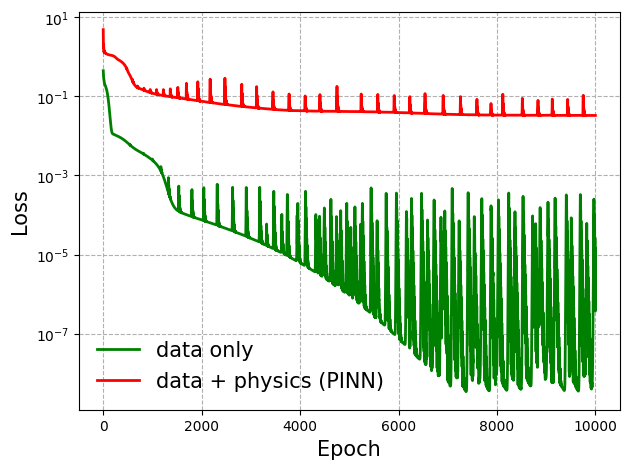

In [11]:
plt.figure()
plt.plot(hist_nn, lw=2, color='green', label="data only")
plt.plot(hist_pinn, lw=2, color='red', label="data + physics (PINN)")

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.yscale('log')
plt.legend(fontsize=15, frameon=False)
plt.grid(ls='--')
plt.tight_layout()
plt.show()

## 6. Result

Inside the data window both fit. Outside it, only the network that knows the equation keeps going.

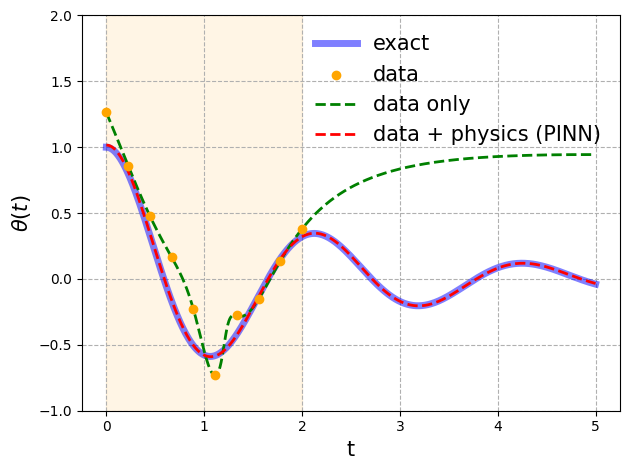

In [12]:
t_eval = torch.tensor(t_span, dtype=torch.float32, device=device).view(-1, 1)
model_nn.eval()
model_pinn.eval()
with torch.no_grad():
    pred_nn = model_nn(t_eval).cpu().numpy().ravel()
    pred_pinn = model_pinn(t_eval).cpu().numpy().ravel()

plt.figure()
plt.plot(t_span, exact_solution(t_span), c='blue', lw=5, alpha=0.5, label="exact")
plt.scatter(t_data, theta_data, c='orange', zorder=3, label="data")
plt.axvspan(0, 2, color='orange', alpha=0.1)
plt.plot(t_span, pred_nn, color='green', ls='--', lw=2, label="data only")
plt.plot(t_span, pred_pinn, color='red', ls='--', lw=2, label="data + physics (PINN)")

plt.ylim(-1., 2.)
plt.xlabel("t", fontsize=15)
plt.ylabel(r"$\theta(t)$", fontsize=15)
plt.legend(fontsize=15, frameon=False)
plt.grid(ls='--')
plt.tight_layout()
plt.show()